In [1]:
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib.pyplot as plt;
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

le = LabelEncoder()

In [2]:
df=pd.read_csv("C:/Users/seema/Downloads/train.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
print(df.columns)
df.info()
print(df.isnull().sum())
print(df.describe())
df["Loan_Status"].value_counts()

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [5]:
df.drop('Loan_ID', axis=1, inplace=True)

In [6]:
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

In [7]:
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

In [8]:
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [9]:
df.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

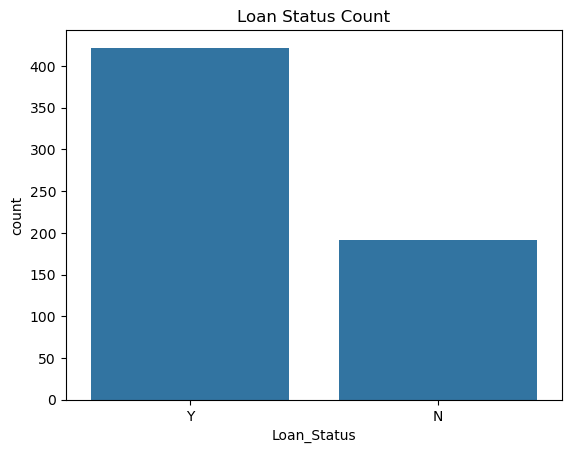

In [10]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Status Count")
plt.show()

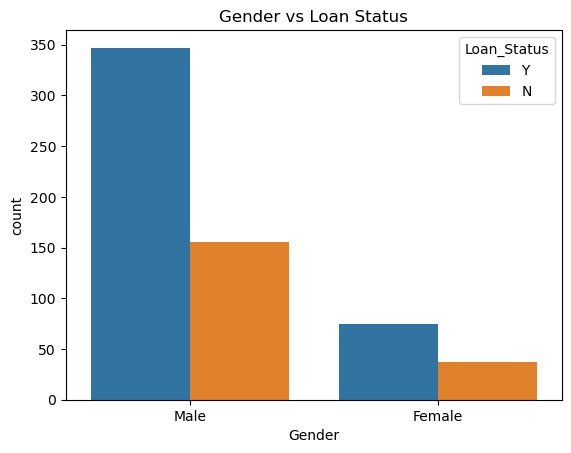

In [11]:
sns.countplot(x='Gender', hue='Loan_Status', data=df)
plt.title("Gender vs Loan Status")
plt.show()

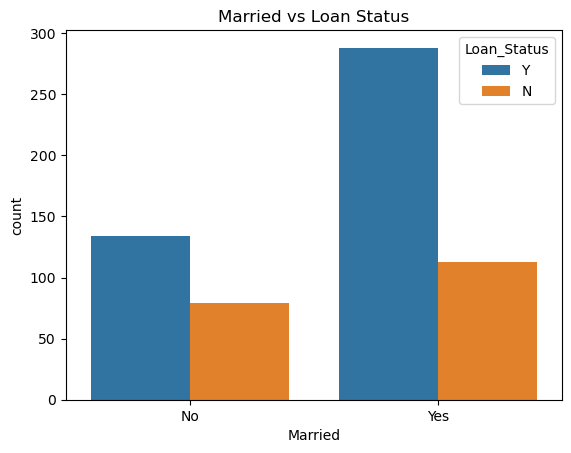

In [12]:
sns.countplot(x='Married', hue='Loan_Status', data=df)
plt.title("Married vs Loan Status")
plt.show()

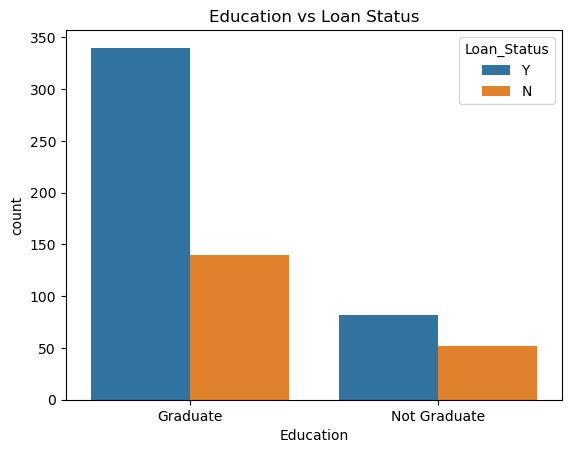

In [13]:
sns.countplot(x='Education', hue='Loan_Status', data=df)
plt.title("Education vs Loan Status")
plt.show()

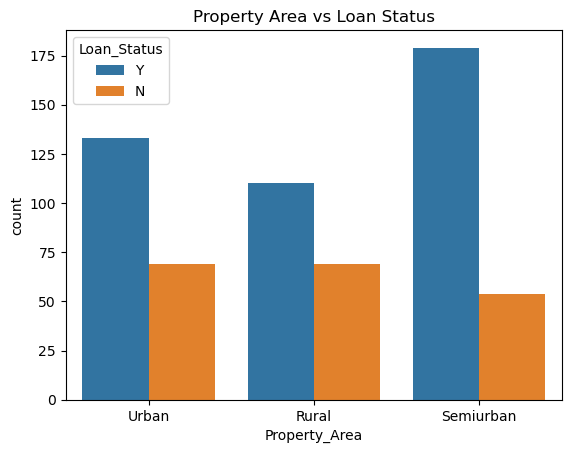

In [14]:
sns.countplot(x='Property_Area', hue='Loan_Status', data=df)
plt.title("Property Area vs Loan Status")
plt.show()

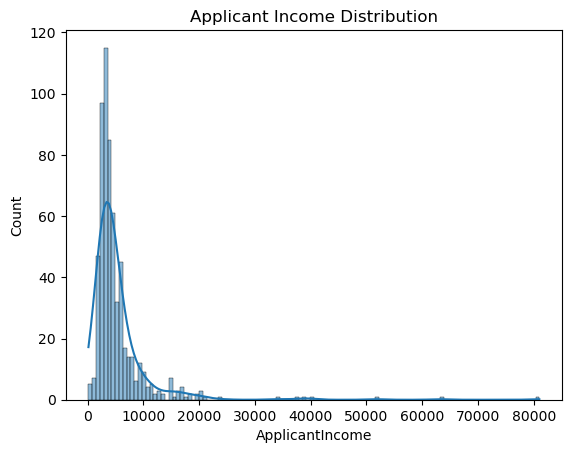

In [15]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.title("Applicant Income Distribution")
plt.show()

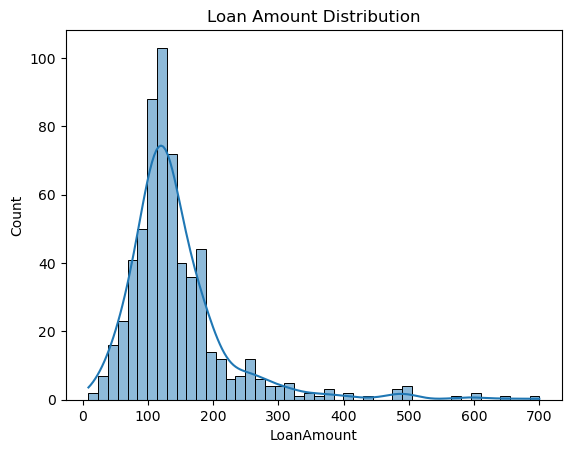

In [16]:
sns.histplot(df['LoanAmount'], kde=True)
plt.title("Loan Amount Distribution")
plt.show()

In [17]:
df['ApplicantIncome_log'] = np.log(df['ApplicantIncome'] + 1)
df['LoanAmount_log'] = np.log(df['LoanAmount'] + 1)

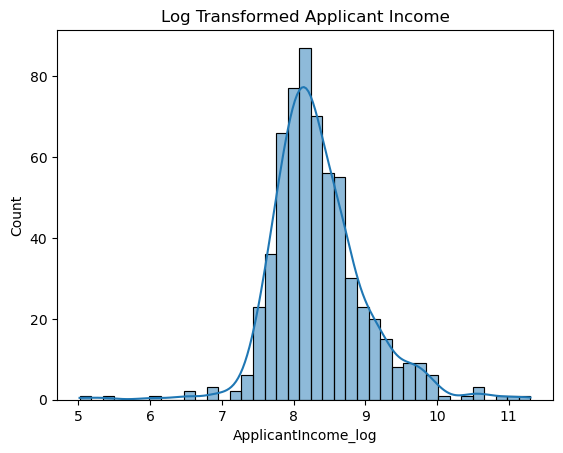

In [18]:
sns.histplot(df['ApplicantIncome_log'], kde=True)
plt.title("Log Transformed Applicant Income")
plt.show()

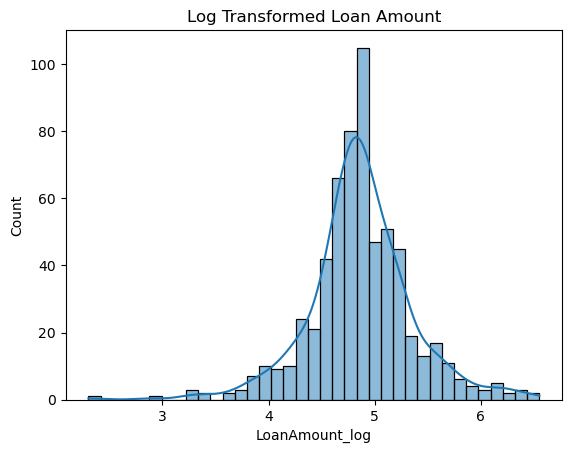

In [19]:
sns.histplot(df['LoanAmount_log'], kde=True)
plt.title("Log Transformed Loan Amount")
plt.show()

In [20]:
df['Dependents'].unique()

array(['0', '1', '2', '3+'], dtype=object)

In [21]:
df['Gender'] = le.fit_transform(df['Gender'])
df['Married'] = le.fit_transform(df['Married'])
df['Education'] = le.fit_transform(df['Education'])
df['Self_Employed'] = le.fit_transform(df['Self_Employed'])
df['Property_Area'] = le.fit_transform(df['Property_Area'])
df['Loan_Status'] = le.fit_transform(df['Loan_Status'])

In [22]:
df['Dependents'] = df['Dependents'].replace('3+', 3)
df['Dependents'] = df['Dependents'].astype(int)

In [23]:
df.drop(['ApplicantIncome', 'LoanAmount'], axis=1, inplace=True)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               614 non-null    int64  
 1   Married              614 non-null    int64  
 2   Dependents           614 non-null    int64  
 3   Education            614 non-null    int64  
 4   Self_Employed        614 non-null    int64  
 5   CoapplicantIncome    614 non-null    float64
 6   Loan_Amount_Term     614 non-null    float64
 7   Credit_History       614 non-null    float64
 8   Property_Area        614 non-null    int64  
 9   Loan_Status          614 non-null    int64  
 10  ApplicantIncome_log  614 non-null    float64
 11  LoanAmount_log       614 non-null    float64
dtypes: float64(5), int64(7)
memory usage: 57.7 KB


In [25]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

In [26]:
X.shape
y.shape

(614,)

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
model = LogisticRegression(max_iter=1000, class_weight='balanced', solver='liblinear')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [44]:
y_pred = model.predict(X_test)

In [45]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7804878048780488


In [46]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[22 21]
 [ 6 74]]


In [47]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.51      0.62        43
           1       0.78      0.93      0.85        80

    accuracy                           0.78       123
   macro avg       0.78      0.72      0.73       123
weighted avg       0.78      0.78      0.77       123



In [48]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

from sklearn.metrics import accuracy_score
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

DT Accuracy: 0.7479674796747967


In [49]:
import pickle
pickle.dump(model, open('loan_model.pkl', 'wb'))